In [1]:
import matplotlib.pyplot as plt

from decluttering.scripts.brio.brio_sensor import BRIOSensor
import datetime
from untangling.utils.interface_rws_BRIO import Interface
import numpy as np
from decluttering.src.motion import *

# SPEED = (0.6, 2 * np.pi)
# iface = Interface(
#             ABB_WHITE.as_frames(YK.l_tcp_frame, YK.l_tip_frame),
#             ABB_WHITE.as_frames(YK.r_tcp_frame, YK.r_tip_frame),
#             speed=SPEED,
#         )
# iface.arms_clear_home()
# iface.sync()
# time = datetime.datetime.now().isoformat()
# print("Time: ", time)

cam = BRIOSensor(0)
img = cam.read()
print(img.shape)

/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


(2121, 3809, 3)


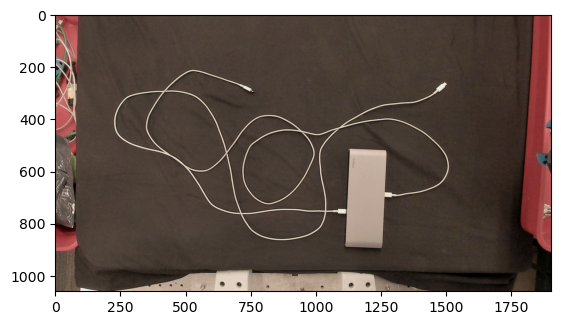

In [2]:
img = cv2.resize(img, (img.shape[1]//2, img.shape[0]//2))
plt.imshow(img)
plt.show()

In [3]:
import PIL.Image as Image
import numpy as np
from decluttering.data.utils.detic_dataloader import DeticDataloader
import matplotlib.pyplot as plt

detic = DeticDataloader()
detic.create()
detic.default_vocab()

/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352465323/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Resetting zs_weight datasets/metadata/lvis_v1_clip_a+cname.npy


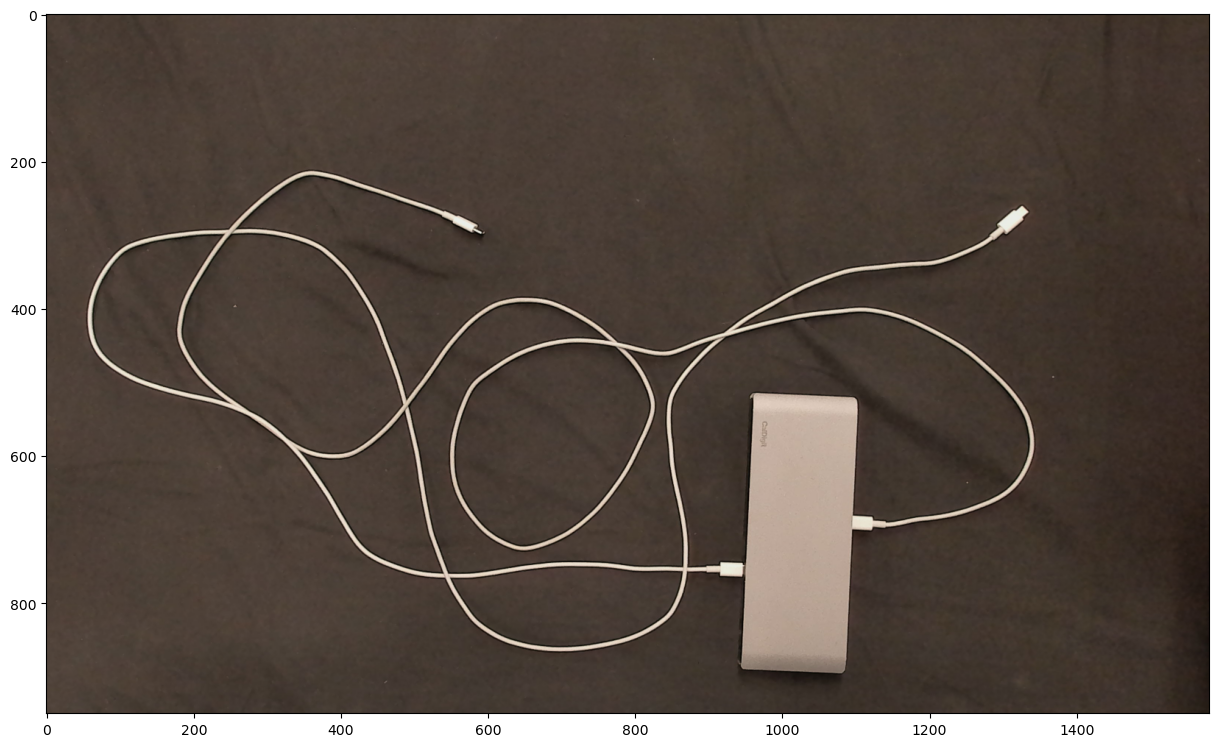

In [4]:
crop_width_left = 85
img = img[0:950, crop_width_left:1750, :3]

# out = detic.predict(img)
# output_im = out['vis'].get_image()
# print(output_im.shape)

plt.figure(figsize=(15, 15))
plt.imshow(img) 
# plt.imsave(f"output_image{time}.png", output_im)


Number of masks before filtering torch.Size([2, 1, 2000, 3300])
Area of masks before filtering tensor([217372,  40605], device='cuda:0')
Proportion of masks before filtering tensor([0.0329, 0.0062], device='cuda:0')
6600000
torch.Size([1, 1, 2000, 3300])
Number of masks after filtering:  1
Proportion of masks after filtering tensor([0.0062], device='cuda:0')


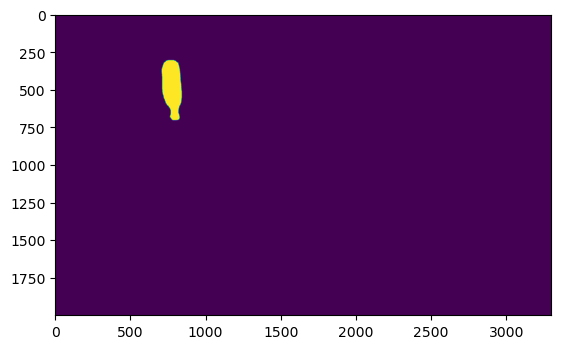

torch.Size([1, 2000, 3300])
tensor(40605, device='cuda:0')


In [5]:
import torch
num_masks = out['masks'].shape[0]
print("Number of masks before filtering", out['masks'].shape)
print("Area of masks before filtering", torch.sum(out['masks'], dim = (1,2,3)))

def filter_mask_by_area(masks, max_area = 0.015, min_area = 0.0007):
    """
    Filter masks by area
    """
    h,w = masks.shape[-2:]
    total_pix = h*w
    print(total_pix)
    mask_areas = torch.sum(masks, dim = (1,2,3))
    mask_areas = mask_areas.cpu().numpy()
    mask_areas = mask_areas.reshape(-1)
    masks_filtered = masks[(mask_areas/total_pix < max_area) & (min_area < mask_areas/total_pix)]
    return masks_filtered

def get_largest_mask(masks):
    sorted, indices = torch.sort(torch.sum(masks, dim = (1,2,3)), descending=True)
    return masks[indices[0]]

h,w = out['masks'].shape[-2:]
total_pix = h*w
print("Proportion of masks before filtering", torch.sum(out['masks'], dim = (1,2,3))/total_pix)

filtered_areas = filter_mask_by_area(out['masks'])
print(filtered_areas.shape)
num_masks = filtered_areas.shape[0]
print("Number of masks after filtering: ", num_masks)
print("Proportion of masks after filtering", torch.sum(filtered_areas, dim = (1,2,3))/total_pix)
# for i in num_masks:
#     plt.imshow(out['masks'][i])
#     plt.show()

plt.imshow(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy())
plt.show()

# plt.imshow(filtered_areas[3].permute((1,2,0)).squeeze(-1).cpu().numpy())
# plt.show()


# sorted, indices = torch.sort(torch.sum(filtered_areas, dim = (1,2,3)), descending=True)
# print(indices)

# print(sorted)

# print(torch.sum(filtered_areas, dim = (1,2,3))[indices[0]])
print(get_largest_mask(filtered_areas).shape)
print(torch.sum(get_largest_mask(filtered_areas)))



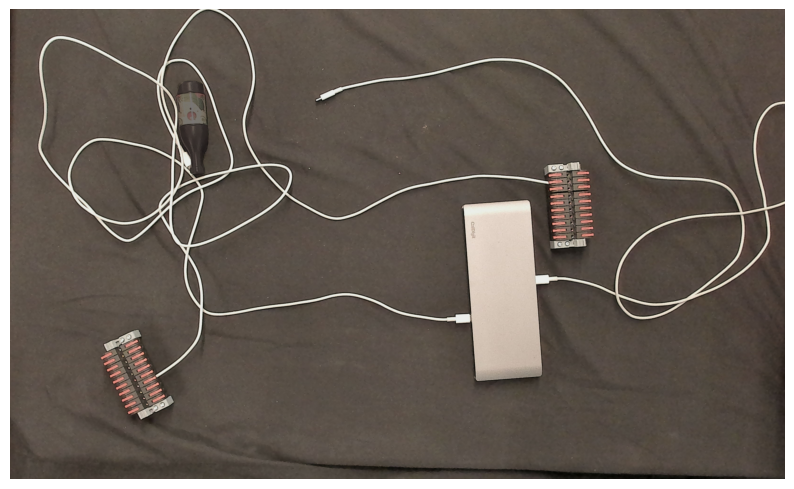

<Figure size 640x480 with 0 Axes>

In [6]:
detic.visualize_output(img, filtered_areas, display='full')


(486.3438000246275, 779.1903460165005)


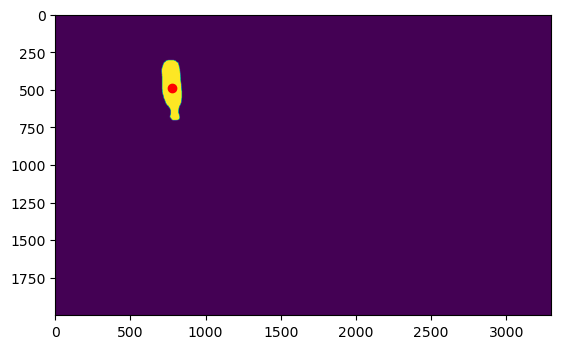

In [7]:
import numpy as np
from scipy.ndimage import center_of_mass

def find_center_of_mass(binary_mask):
    """
    Find the center of mass of pixels given a binary mask image.
    
    Parameters:
    binary_mask (numpy.ndarray): A 2D numpy array representing the binary mask image.

    Returns:
    tuple: The (row, column) coordinates of the center of mass.
    """
    # Ensure the input is a binary mask
    binary_mask = np.asarray(binary_mask, dtype=bool)
    
    # Calculate the center of mass
    center = center_of_mass(binary_mask)
    
    return center

center = find_center_of_mass(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy())

print(center)

# plot with center
plt.imshow(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy())
plt.scatter(center[1], center[0], c='r')


In [8]:
out['boxes'][0]

height = abs(out['boxes'][0][0] - out['boxes'][0][1])
print(height)
width = abs(out['boxes'][0][2] - out['boxes'][0][3])
print(width)

if height > width:
    print('vertical')
else:
    print('horizontal')

1109.9379
685.89026
vertical


The oriented bounding box is: ((777.9810180664062, 505.1775817871094), (400.60162353515625, 129.12973022460938), 86.633544921875)


/tmp/ipykernel_4176858/302404812.py:42: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  box = np.int0(box)


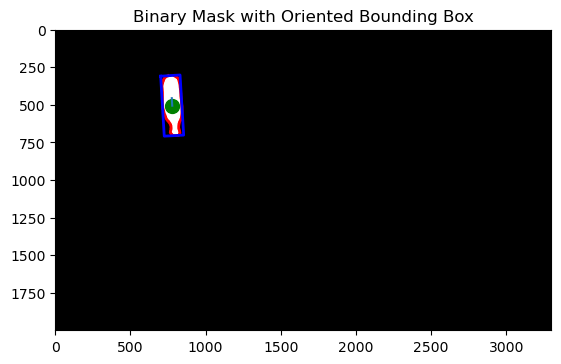

-0.05872192463772925
-0.9982743788993289


In [9]:
import cv2
import numpy as np

def get_oriented_bounding_box(binary_mask):
    """
    Fit the tightest oriented bounding box around a 2D binary mask.
    
    Parameters:
    binary_mask (numpy.ndarray): A 2D numpy array representing the binary mask image.
    
    Returns:
    tuple: The (center (x, y), (width, height), angle of rotation) of the bounding box.
    """
    # Ensure the input is a binary mask
    binary_mask = np.asarray(binary_mask, dtype=np.uint8)
    
    # Find contours in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Get the largest contour, assuming the mask is connected
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Get the minimum area bounding rectangle
    rect = cv2.minAreaRect(largest_contour)
    
    return rect, largest_contour


rect, contour = get_oriented_bounding_box(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy())
print(f"The oriented bounding box is: {rect}")

def plot_mask_with_bbox(binary_mask, rect, contour):
    """
    Plot the binary mask with the oriented bounding box.
    
    Parameters:
    binary_mask (numpy.ndarray): A 2D numpy array representing the binary mask image.
    rect (tuple): The (center (x, y), (width, height), angle of rotation) of the bounding box.
    contour (numpy.ndarray): Contour of the largest component in the binary mask.
    """
    box = cv2.boxPoints(rect)
    box = np.int0(box)

    angle = rect[2]
    if rect[1][0] > rect[1][1]:
        angle = angle + 90
    
    plt.figure()
    plt.imshow(binary_mask, cmap='gray')
    plt.plot(contour[:, 0, 0], contour[:, 0, 1], 'r', linewidth=2)
    plt.plot(*zip(*np.vstack([box, box[0]])), 'b-', linewidth=2)
    plt.scatter(rect[0][0], rect[0][1], color='green', s=100)
    plt.plot([rect[0][0], rect[0][0]-50*np.sin(np.radians(angle))], [rect[0][1], rect[0][1]+50*np.cos(np.radians(angle))])
    plt.title("Binary Mask with Oriented Bounding Box")
    plt.show()

plot_mask_with_bbox(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy(), rect, contour)

center = np.array(rect[0])
angle = rect[2]
if rect[1][0] > rect[1][1]:
    angle = angle + 90
    
print(-np.sin(np.radians(angle)))
print(np.cos(np.radians(angle)))


In [10]:

iface.arms_clear_home()
iface.sync()
iface.open_grippers()
iface.sync()

print("Angle is: ", angle)

center = center + np.array([crop_width_left, 0])
perform_point_grasp(center, np.radians(angle), iface)


Info:    RRTConnect: Starting planning with 1 states already in datastructure
move joints
Info:    RRTConnect: Created 4 states (2 start + 2 goal)
Info:    Solution found in 0.002221 seconds
Info:    SimpleSetup: Path simplification took 0.017684 seconds and changed from 3 to 2 states
Solution cost 5.67543e-06
Angle is:  176.633544921875
[977.98101807 505.17758179]
Using left arm
[0.5479960258070246, 0.252087508176192, 0.058]
Jump of magnitude 6.235335270080563 found in joint 6
Jump of magnitude 6.235335279389261 found in joint 6
for: [-1.46361285 -1.05347465  1.24809936 -0.20013361  1.84130351  1.15017986
  3.48331509]
back: [-1.46070314 -1.03567483  1.26748053 -0.20631674  1.82036375  1.13311059
 -1.80134138]
target norm: 5.284795451316656
aborting shake action, no smooth IK found between shake poses
Jump of magnitude 6.279234324393811 found in joint 6
Jump of magnitude 6.279241377497702 found in joint 6
Jump of magnitude 6.27922188406777 found in joint 6
Jump of magnitude 6.27922394

: 